# AOD DDS Lab Control Notebook — v1.0

**Purpose:** Control and test the Spectrum M4i.6622-x8 DDS on the lab computer, first with an oscilloscope and later with the AOD.

### Hardware
- AWG / DDS card: **Spectrum M4i.6622-x8**
- Serial number: **23161**
- Device handle: **`/dev/spcm0`**
- Output channel: **CH0**
- AOD: **AA Opto-Electronic DTSX-400-800**

### Reference
Spectrum `spcm` DDS examples:  
`https://github.com/SpectrumInstrumentation/spcm/tree/master/src/examples/03_dds`

Main references used here:
- `01_dds_single_static_carrier.py`
- `02_dds_multiple_static_carriers.py`

### Recommended test order
1. Environment check
2. Card connection check
3. DDS initialization check
4. CH0 → Scope: single tone
5. Verify frequency and amplitude on scope
6. CH0 → Scope: multiple tones
7. Only after electrical verification: amplifier / AOD test

**Important:** Run cells manually from top to bottom. Do not connect the RF amplifier or AOD until the direct AWG → Scope test is understood.


## 1. Environment Check

This cell does not control the hardware. It only checks the Python environment and imports `spcm`.


In [9]:
import sys
import math
import spcm
from spcm import units
from Equipments import LeCroyScope
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft, fftfreq

print("Python:", sys.version.split()[0])
print("spcm imported successfully")


Python: 3.13.12
spcm imported successfully


## 2. Main Lab Configuration

**Most hardware settings should be changed here.**

For the present setup, the values below should normally stay unchanged.


In [14]:
# ============================================================
# LAB HARDWARE SETTINGS
# ============================================================

DEVICE = "/dev/spcm0"
EXPECTED_MODEL = "M4i.6622-x8"
EXPECTED_SERIAL = 23161

CHANNEL = spcm.CHANNEL0
LOAD = 50 * units.ohm

print("Device:", DEVICE)
print("Expected model:", EXPECTED_MODEL)
print("Expected serial:", EXPECTED_SERIAL)


Device: /dev/spcm0
Expected model: M4i.6622-x8
Expected serial: 23161


## 3. Card Connection Check

Opens the card, reads its identity, verifies the model and serial number, then closes it.

No DDS configuration and no RF output are used here.


In [15]:
with spcm.Card(DEVICE) as card:
    model = card.product_name()
    serial = card.sn()

    print("Connected successfully")
    print("Model:", model)
    print("Serial:", serial)

    if model != EXPECTED_MODEL:
        raise RuntimeError(f"Unexpected card model: {model}")

    if serial != EXPECTED_SERIAL:
        raise RuntimeError(f"Unexpected serial number: {serial}")

print("Connection check passed")


Connected successfully
Model: M4i.6622-x8
Serial: 23161
Connection check passed


## 4. DDS Initialization Check

Verifies that the M4i.6622-x8 can enter DDS mode and create a DDS object.

This cell still does **not** start RF output.


In [4]:
with spcm.Card(DEVICE) as card:

    card.card_mode(spcm.SPC_REP_STD_DDS)

    channels = spcm.Channels(card, card_enable=CHANNEL)
    channels[0].enable(True)
    channels[0].output_load(LOAD)

    # Required for DDS clock/setup
    card.write_setup()

    dds = spcm.DDS(card, channels=channels)
    dds.reset()

    print("DDS initialized successfully")
    print("Available DDS cores:", len(dds))

print("DDS initialization check passed")


DDS initialized successfully
Available DDS cores: 23
DDS initialization check passed


## 5. Single-Tone Scope Test — Settings

Use this section for the first physical test:

`M4i CH0 → 50 Ω coax → Scope`

The values below are **scope-test values**, not the final AOD operating settings.

Before running the output cell:
- connect **CH0** to the scope;
- use a **50 Ω** scope input, or a 50 Ω terminator with a 1 MΩ input;
- do not connect the RF amplifier yet.


In [17]:
# ============================================================
# SINGLE-TONE SCOPE TEST SETTINGS
# ============================================================

CHANNEL_RANGE = 0.5 * units.V

TEST_FREQUENCY = 10 * units.MHz
TEST_AMPLITUDE = 100 * units.mV
TEST_PHASE = 0 * units.degrees

print("Frequency:", TEST_FREQUENCY)
print("DDS amplitude:", TEST_AMPLITUDE)
print("Phase:", TEST_PHASE)


Frequency: 10 MHz
DDS amplitude: 100 mV
Phase: 0 deg


## 6. Single-Tone RF Output

This cell starts one DDS carrier on CH0.

The RF stays on until you press **Enter**.  
The `finally` block stops the card even if an error occurs after output starts.


In [8]:
with spcm.Card(DEVICE) as card:

    card.card_mode(spcm.SPC_REP_STD_DDS)

    channels = spcm.Channels(card, card_enable=CHANNEL)
    channels[0].enable(True)
    channels[0].output_load(LOAD)
    channels[0].amp(CHANNEL_RANGE)

    card.write_setup()

    dds = spcm.DDS(card, channels=channels)
    dds.reset()

    dds[0].freq(TEST_FREQUENCY)
    dds[0].amp(TEST_AMPLITUDE)
    dds[0].phase(TEST_PHASE)

    print("Programmed frequency:",
          dds[0].get_freq(return_unit=units.MHz))
    print("Programmed amplitude:",
          dds[0].get_amp(return_unit=units.mV))
    print("Programmed phase:",
          dds[0].get_phase(return_unit=units.degrees))

    dds.exec_at_trg()
    dds.write_to_card()

    try:
        card.start(
            spcm.M2CMD_CARD_ENABLETRIGGER,
            spcm.M2CMD_CARD_FORCETRIGGER
        )

        print("\nRF output ON")
        input("Press Enter to stop RF output...")

    finally:
        card.stop()
        print("RF output OFF")


Programmed frequency: 9.999999892897904 MHz
Programmed amplitude: 99.9938962981048 mV
Programmed phase: 0.0 deg

RF output ON


Press Enter to stop RF output... 


RF output OFF


## 7. Scope Measurement / RF Power Estimate

After measuring the sine wave on the scope, enter the measured **Vpp in volts** below.

For a sine wave into 50 Ω:

\[
P = \frac{V_{pp}^2}{8R}
\]

This is useful for checking the electrical signal before adding the RF amplifier.


In [9]:
# Enter the measured scope value in volts.
# Example: 0.20 means 0.20 Vpp.
MEASURED_VPP_V = 0.192

R_OHM = 50

if MEASURED_VPP_V is None:
    print("Enter MEASURED_VPP_V after taking a scope measurement.")
else:
    power_W = MEASURED_VPP_V**2 / (8 * R_OHM)
    power_mW = 1000 * power_W
    power_dBm = 10 * math.log10(power_mW)

    print(f"Measured Vpp: {MEASURED_VPP_V:.6g} V")
    print(f"Estimated power into 50 Ω: {power_W:.6g} W")
    print(f"Estimated power: {power_mW:.6g} mW")
    print(f"Estimated power: {power_dBm:.3f} dBm")


Measured Vpp: 0.192 V
Estimated power into 50 Ω: 9.216e-05 W
Estimated power: 0.09216 mW
Estimated power: -10.355 dBm


## 8. Multi-Tone Scope Test — Settings

Only use this after the single-tone test works.

Start with **2 tones**, then increase gradually.

The total DDS amplitude budget is divided equally among the tones.


In [12]:
# ============================================================
# MULTI-TONE TEST SETTINGS
# ============================================================

MULTI_FREQUENCIES = [
    100 * units.MHz,
    110 * units.MHz,
]

MULTI_TOTAL_AMPLITUDE = 10 * units.percent
MULTI_PHASE = 0 * units.degrees

print("Number of tones:", len(MULTI_FREQUENCIES))
print("Frequencies:", MULTI_FREQUENCIES)
print("Total DDS amplitude budget:", MULTI_TOTAL_AMPLITUDE)


Number of tones: 2
Frequencies: [<Quantity(100, 'megahertz')>, <Quantity(110, 'megahertz')>]
Total DDS amplitude budget: 10 %


## 9. Multi-Tone RF Output

This cell assigns one DDS core to each frequency.

If the scope has FFT, use it to verify that all programmed tones are present.


In [18]:
with spcm.Card(DEVICE) as card:

    card.card_mode(spcm.SPC_REP_STD_DDS)

    channels = spcm.Channels(card, card_enable=CHANNEL)
    channels[0].enable(True)
    channels[0].output_load(LOAD)
    channels[0].amp(CHANNEL_RANGE)

    card.write_setup()

    dds = spcm.DDS(card, channels=channels)
    dds.reset()

    num_tones = len(MULTI_FREQUENCIES)

    if num_tones > len(dds):
        raise ValueError(
            f"Requested {num_tones} tones, but only {len(dds)} DDS cores are available."
        )

    amplitude_per_tone = MULTI_TOTAL_AMPLITUDE / num_tones

    for i, frequency in enumerate(MULTI_FREQUENCIES):
        dds[i].freq(frequency)
        dds[i].amp(amplitude_per_tone)
        dds[i].phase(MULTI_PHASE)

        print(
            f"Core {i}: "
            f"{dds[i].get_freq(return_unit=units.MHz)}, "
            f"{dds[i].get_amp(return_unit=units.percent)}"
        )

    dds.exec_at_trg()
    dds.write_to_card()

    try:
        card.start(
            spcm.M2CMD_CARD_ENABLETRIGGER,
            spcm.M2CMD_CARD_FORCETRIGGER
        )

        print("\nMulti-tone RF output ON")
        input("Press Enter to stop RF output...")

    finally:
        card.stop()
        print("RF output OFF")


Core 0: 100.00000009313226 MHz, 0.0499893185216834 %
Core 1: 109.99999998603016 MHz, 0.0499893185216834 %

Multi-tone RF output ON


Press Enter to stop RF output... 


RF output OFF


*IDN -> LECROY,9354AM,935403739,08.2.1



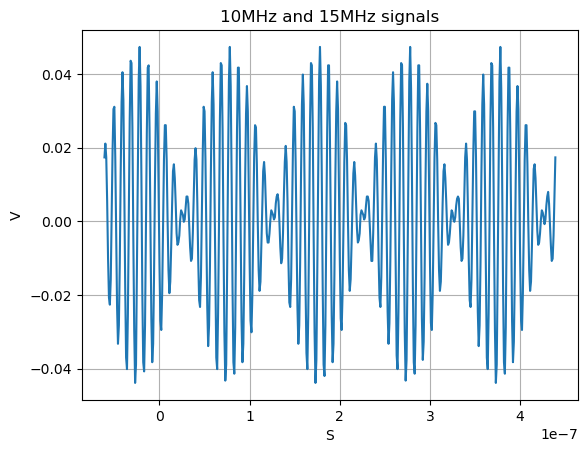

In [19]:
# connect to LeCroy 9354AM oscilloscope (for displaying DEI pulse and Rydberg counts for both states)
lecroy = LeCroyScope.LeCroyScope('GPIB0::3::INSTR', timeout = 20000)
lecroy.setup_transfer()
t, v, info = lecroy.read_waveform("C2")
plt.plot(t, v)
plt.xlabel(info["horizontal_unit"] or "s")
plt.ylabel(info["vertical_unit"] or "V")
plt.title("10MHz and 15MHz signals")
plt.grid(True)
plt.show()
lecroy.close()

In [10]:
t.max()

np.float64(8.799399717180685e-07)

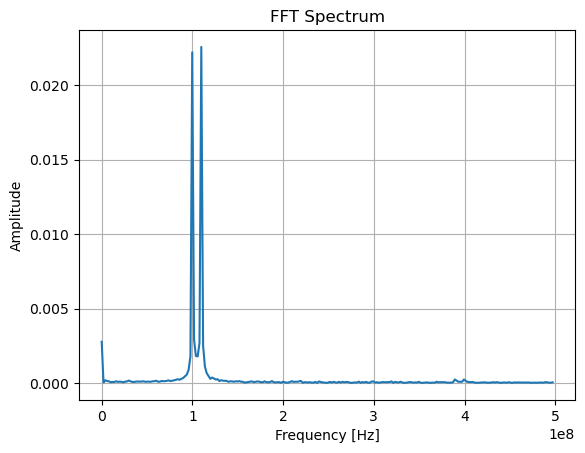

In [20]:
sample_rate = 1e9  # Hz
duration = t.max()     # seconds

# Compute FFT
yf = fft(v)
xf = fftfreq(len(t), 1 / sample_rate)

# Plot positive frequencies only
positive_freqs = len(t) // 2
plt.plot(xf[:positive_freqs], 2.0 / len(t) * np.abs(yf[:positive_freqs]))
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.title('FFT Spectrum')
plt.grid()
plt.show()

## 10. AOD Specifications / Future AOD Test Settings

AOD: **AA Opto-Electronic DTSX-400-800**

Known values:
- optical wavelength range: approximately 780–820 nm
- active aperture: approximately 7.5 × 7.5 mm²
- RF input impedance: 50 Ω
- RF frequency span / range: approximately 36 MHz
- maximum RF power at the AOD input: < 2 W

The exact **center frequency / usable RF endpoints for this physical AOD** should be taken from its calibration sheet or unit documentation.

Do not interpret the AWG DDS amplitude setting as the RF power delivered to the AOD. The later chain is:

`M4i CH0 → RF amplifier → cable / loss → AOD`

The RF power limit applies at the **AOD RF input**.


In [21]:
# ============================================================
# AOD INFORMATION
# ============================================================

AOD_MODEL = "DTSX-400-800"
AOD_RF_SPAN = 36 * units.MHz
AOD_IMPEDANCE = 50 * units.ohm
AOD_MAX_RF_POWER = 2 * units.W

# Fill these from the calibration sheet of the actual AOD:
AOD_CENTER_FREQUENCY = None
AOD_RF_MIN = None
AOD_RF_MAX = None

print("AOD model:", AOD_MODEL)
print("RF span:", AOD_RF_SPAN)
print("Maximum RF power at AOD input:", AOD_MAX_RF_POWER)

if AOD_CENTER_FREQUENCY is None:
    print("AOD center frequency: NOT YET ENTERED")


AOD model: DTSX-400-800
RF span: 36 MHz
Maximum RF power at AOD input: 2 W
AOD center frequency: NOT YET ENTERED


## 11. AOD Frequency Readiness Check

Run this before using the actual AOD frequency settings.

It intentionally refuses to proceed until the unit-specific RF frequency information has been entered.


In [ ]:
if AOD_CENTER_FREQUENCY is None:
    raise ValueError(
        "AOD center frequency is not set. "
        "Enter the value from the calibration sheet before an AOD RF test."
    )

print("AOD center frequency:", AOD_CENTER_FREQUENCY)

if AOD_RF_MIN is not None and AOD_RF_MAX is not None:
    print("AOD RF interval:", AOD_RF_MIN, "to", AOD_RF_MAX)

print("AOD frequency information is ready.")


## 12. Emergency / Manual Stop

If an output cell is interrupted and you are unsure whether the card is still running, run this cell.

This does not replace physically disconnecting or disabling the RF chain when required.


In [ ]:
with spcm.Card(DEVICE) as card:
    card.stop()

print("Stop command sent to M4i.6622-x8")


## 13. Quick Troubleshooting

### `import spcm` fails
Check the Python / Jupyter environment and install `spcm` in the same environment.

### Card cannot open
Check:
- Spectrum driver
- `/dev/spcm0`
- card permissions
- Spectrum Control Center

### Model / serial check fails
Stop and verify which physical card is being opened.

### DDS initialization fails
Check:
- DDS firmware / feature
- driver and `spcm` version
- card mode and channel configuration

### Scope shows no signal
Check:
- correct physical connector: **CH0**
- 50 Ω coax
- scope channel enabled
- 50 Ω termination
- output cell actually reached `RF output ON`
- frequency/time-base settings on the scope

### Frequency is correct but amplitude is unexpected
Check:
- scope termination (50 Ω vs 1 MΩ)
- channel range
- DDS amplitude
- cable / adapters
- whether the scope reports Vpp, Vrms, or another quantity

### Before connecting the AOD
Confirm:
- unit-specific AOD RF frequency range
- RF amplifier gain
- output power after the amplifier
- cable / coupler loss
- final RF power delivered to the AOD is below its allowed limit
